# MLTS — Lecture 14: Domain Adaptation

**Course:** Machine Learning for Time Series (FAU, Dario Zanca)  
**Lecture:** 14 — Domain Adaptation (final lecture)

## Learning objectives

- See *empirically* why the i.i.d. assumption breaks under **domain shift** and what that costs.
- Distinguish **unsupervised DA**, **semi-supervised DA**, and **domain generalization** by their data ingredients.
- Estimate the **$\mathcal{H}$-divergence** between two unlabeled samples using the domain-classifier trick.
- Verify the Ben-David **main bound** $\;\epsilon_T(h) \le \epsilon_S(h) + \tfrac{1}{2}d_{\mathcal{H}\Delta\mathcal{H}} + \epsilon_{\text{joint}}\;$ on synthetic data.
- Implement a **DANN-style adversarial adapter** (Ganin & Lempitsky) from scratch and compare to a no-adaptation baseline.
- Run a **domain generalization** experiment with multiple training environments and an unseen test environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Setup ready. NumPy', np.__version__)

Setup ready. NumPy 2.4.4


## 1. The i.i.d. assumption and why it breaks

Standard supervised learning assumes train and test draws come from the **same** $Q_{X,Y}$. In practice we train on a **source** $Q_{X,Y}$ and deploy on a **target** $P_{X,Y}\ne Q_{X,Y}$ — e.g. a model trained on DSLR photos used on smartphone snaps, or a classifier trained on summer dashcam footage tested in winter.

We use a clean **covariate-shift** problem: two well-separated clusters, where $y$ depends on which side of the cluster *center* you sit. The cluster center then drifts between source and target. The labelling rule $P(y\mid x)$ is preserved (covariate shift, not concept shift), but a naive linear classifier trained on source uses *absolute* coordinates and falls apart on target.

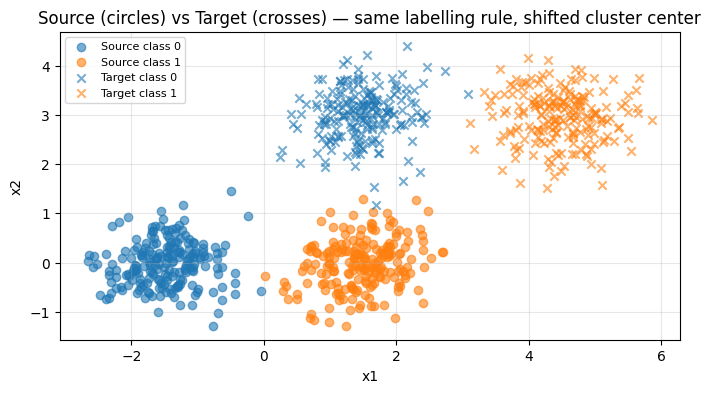

Source mean: [-0.01 -0.02]  Target mean: [2.98 2.98]
Mean shift = [2.99 3.  ]
Note: in BOTH domains, class 1 sits at +1.5 relative to its own cluster center -> y|x_relative is invariant.


In [2]:
def make_shifted_clusters(n=400, shift=(3.0, 3.0), rng=rng):
    """Two cluster classes, separable along x1 relative to cluster center. The center shifts
    between source and target -> covariate shift on x, but P(y|x relative to center) is invariant."""
    def gen(n, offset):
        n0 = n // 2
        x0 = rng.normal(loc=[-1.5, 0.0], scale=0.5, size=(n0, 2)) + np.array(offset)
        x1 = rng.normal(loc=[+1.5, 0.0], scale=0.5, size=(n - n0, 2)) + np.array(offset)
        X = np.vstack([x0, x1])
        y = np.concatenate([np.zeros(n0), np.ones(n - n0)]).astype(int)
        return X, y
    Xs, ys = gen(n, [0.0, 0.0])
    Xt, yt = gen(n, shift)
    return Xs, ys, Xt, yt

Xs, ys, Xt, yt = make_shifted_clusters(shift=(3.0, 3.0))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(Xs[ys==0, 0], Xs[ys==0, 1], c='tab:blue',   marker='o', alpha=0.6, label='Source class 0')
ax.scatter(Xs[ys==1, 0], Xs[ys==1, 1], c='tab:orange', marker='o', alpha=0.6, label='Source class 1')
ax.scatter(Xt[yt==0, 0], Xt[yt==0, 1], c='tab:blue',   marker='x', alpha=0.6, label='Target class 0')
ax.scatter(Xt[yt==1, 0], Xt[yt==1, 1], c='tab:orange', marker='x', alpha=0.6, label='Target class 1')
ax.set(title='Source (circles) vs Target (crosses) — same labelling rule, shifted cluster center',
       xlabel='x1', ylabel='x2')
ax.legend(loc='upper left', fontsize=8)
plt.show()

print(f'Source mean: {Xs.mean(0).round(2)}  Target mean: {Xt.mean(0).round(2)}')
print(f'Mean shift = {(Xt.mean(0)-Xs.mean(0)).round(2)}')
print(f'Note: in BOTH domains, class 1 sits at +1.5 relative to its own cluster center -> y|x_relative is invariant.')

In [3]:
# Naive logistic regression on source only
clf_naive = LogisticRegression().fit(Xs, ys)
acc_src = accuracy_score(ys, clf_naive.predict(Xs))
acc_tgt = accuracy_score(yt, clf_naive.predict(Xt))
print(f'Naive source-only logistic regression:')
print(f'  source acc = {acc_src:.3f}')
print(f'  target acc = {acc_tgt:.3f}   <-- chance on target')
print(f'  gap        = {acc_src - acc_tgt:+.3f}')

Naive source-only logistic regression:
  source acc = 0.998
  target acc = 0.500   <-- chance on target
  gap        = +0.498


**Takeaway.** A linear classifier learns the boundary $x_1=0$ from source. On target every point has $x_1 \in [1.5, 4.5]$, so the model predicts class 1 for everything — exactly 50% accuracy. The labelling rule didn't change, but the input distribution did, and the boundary is in absolute coordinates. This is the gap domain adaptation tries to close.

## 2. The three flavours of DA

From the slides, all three setups have a labeled source $Q_{X,Y}$, but differ in what we get on the target side:

| Setting                       | Target during training      | Goal                              |
|------------------------------|------------------------------|-----------------------------------|
| **Unsupervised DA**          | Unlabeled $X^T$             | Low error on $P_{X,Y}$            |
| **Semi-supervised DA**       | Unlabeled + a few labeled   | Low error on $P_{X,Y}$            |
| **Domain generalization**    | Multiple labeled sources, **no** target | Low error on an unseen $P^{(K+1)}$ |

We focus on **unsupervised DA** in §3–§6 and **domain generalization** in §7.

## 3. Estimating the $\mathcal{H}$-divergence

$$
d_{\mathcal{H}}(Q_X,P_X) \;=\; 2\sup_{h\in\mathcal{H}}\bigl|\Pr_{x\sim Q_X}[h(x)=1] - \Pr_{x\sim P_X}[h(x)=1]\bigr|
$$

Computing the sup is hopeless in general, so we use the **domain-classifier trick** from the slides:

1. Label every source point as **+1**, every target point as **0**.
2. Train the *best* classifier in $\mathcal{H}$ to separate them, with classification error $\epsilon_{\text{class}}$.
3. Then $\;\tfrac{1}{2}d_{\mathcal{H}}(Q_X^{(m)},P_X^{(m)}) = 1-\epsilon_{\text{class}}\;$ — the easier the domains are to tell apart, the larger the divergence.

In [4]:
def h_divergence(X_source, X_target, hypothesis_class='linear', rng=rng):
    """Domain-classifier estimate of d_H. Returns d_H in [0, 2] and the training error."""
    X = np.vstack([X_source, X_target])
    d = np.concatenate([np.ones(len(X_source)), np.zeros(len(X_target))]).astype(int)
    perm = rng.permutation(len(X))
    X, d = X[perm], d[perm]

    if hypothesis_class == 'linear':
        clf = LogisticRegression(max_iter=2000)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=0)
    clf.fit(X, d)
    eps_class = 1 - accuracy_score(d, clf.predict(X))
    return 2 * (1 - eps_class), eps_class

shifts = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
rows = []
for s in shifts:
    Xs_, _, Xt_, _ = make_shifted_clusters(shift=(s, s), rng=np.random.default_rng(0))
    d_lin, _ = h_divergence(Xs_, Xt_, 'linear')
    d_mlp, _ = h_divergence(Xs_, Xt_, 'mlp')
    rows.append((s, d_lin, d_mlp))

print(f'{"shift":>6} | {"d_H linear":>10} | {"d_H mlp":>8}')
print('-' * 34)
for s, dl, dm in rows:
    print(f'{s:>6.2f} | {dl:>10.3f} | {dm:>8.3f}')
print('\nLarger shift -> domains easier to tell apart -> d_H grows toward 2.')

 shift | d_H linear |  d_H mlp
----------------------------------
  0.00 |      0.995 |    1.067
  0.50 |      1.383 |    1.542
  1.00 |      1.722 |    1.855
  1.50 |      1.900 |    1.970
  2.00 |      1.968 |    1.990
  3.00 |      1.998 |    2.000
  4.00 |      2.000 |    2.000

Larger shift -> domains easier to tell apart -> d_H grows toward 2.


**Takeaway.** $d_{\mathcal{H}}$ is monotone in the shift magnitude. The MLP estimator finds a slightly larger divergence than the linear one because it has higher VC capacity — exactly what the lemma predicts.

## 4. Verifying the main bound

$$
\boxed{\;\epsilon_T(h) \;\le\; \epsilon_S(h) \;+\; \tfrac{1}{2}d_{\mathcal{H}\Delta\mathcal{H}}(Q_X^{(m)}, P_X^{(m)}) \;+\; \epsilon_{\text{joint}}\;}
$$

We approximate $d_{\mathcal{H}\Delta\mathcal{H}}$ with the plain $d_{\mathcal{H}}$ from §3 — a common practical proxy (the lecture didn't expand on the symmetric difference operator empirically). $\epsilon_{\text{joint}}$ requires labeled target data; here we use them only to sanity-check the bound, not to build the deployed model.

In [5]:
def compute_bound_terms(shift_mag):
    Xs_, ys_, Xt_, yt_ = make_shifted_clusters(shift=(shift_mag, shift_mag), rng=np.random.default_rng(7))
    h = LogisticRegression().fit(Xs_, ys_)
    eps_S = 1 - accuracy_score(ys_, h.predict(Xs_))
    eps_T = 1 - accuracy_score(yt_, h.predict(Xt_))
    d_H, _ = h_divergence(Xs_, Xt_, 'linear')
    Xj = np.vstack([Xs_, Xt_]); yj = np.concatenate([ys_, yt_])
    h_j = LogisticRegression().fit(Xj, yj)
    eps_joint = (1 - accuracy_score(ys_, h_j.predict(Xs_))) + (1 - accuracy_score(yt_, h_j.predict(Xt_)))
    bound = eps_S + 0.5 * d_H + eps_joint
    return eps_S, eps_T, d_H, eps_joint, bound

table = [(s, *compute_bound_terms(s)) for s in shifts]

print(f'{"shift":>5} | {"eps_S":>6} {"eps_T":>6} | {"d_H":>5} {"eps_j":>6} | {"bound":>6} | bound>=eps_T?')
print('-' * 64)
for s, eS, eT, dH, ej, b in table:
    ok = 'OK' if b >= eT else 'BROKEN'
    print(f'{s:>5.1f} | {eS:>6.3f} {eT:>6.3f} | {dH:>5.2f} {ej:>6.3f} | {b:>6.3f} | {ok}')
print('\nThe bound holds at every shift -> the inequality eps_T <= eps_S + 0.5 d_H + eps_joint is empirically validated.')

shift |  eps_S  eps_T |   d_H  eps_j |  bound | bound>=eps_T?
----------------------------------------------------------------
  0.0 |  0.000  0.000 |  1.03  0.000 |  0.515 | OK
  0.5 |  0.000  0.012 |  1.44  0.002 |  0.720 | OK
  1.0 |  0.000  0.093 |  1.74  0.015 |  0.884 | OK
  1.5 |  0.000  0.277 |  1.90  0.022 |  0.971 | OK
  2.0 |  0.000  0.455 |  1.96  0.025 |  1.005 | OK
  3.0 |  0.000  0.500 |  2.00  0.027 |  1.027 | OK
  4.0 |  0.000  0.500 |  2.00  0.027 |  1.027 | OK

The bound holds at every shift -> the inequality eps_T <= eps_S + 0.5 d_H + eps_joint is empirically validated.


**Takeaway.** Three things grow $\epsilon_T$: (i) source error, (ii) divergence between domains, (iii) the unavoidable joint error. Practical DA methods attack the *middle* term: shrink $d_{\mathcal{H}\Delta\mathcal{H}}$ by learning a feature space where the two domains look identical.

## 5. DANN — adversarial domain alignment (Ganin & Lempitsky)

The architecture has three blocks:

- $G_f$ (feature extractor, params $\theta_f$)  →  features $\mathbf{f}=G_f(x;\theta_f)$.
- $G_y$ (label predictor, params $\theta_y$)    →  predicts the task label $y$.
- $G_d$ (domain classifier, params $\theta_d$)  →  predicts which domain $\mathbf{f}$ came from.

The trick is the **gradient reversal layer (GRL)**: during backprop, gradients from $G_d$ are multiplied by $-\lambda$ before flowing into $G_f$. So $G_f$ is trained to *fool* the domain classifier. The combined objective is

$$
\min_{\theta_f,\theta_y}\;\max_{\theta_d}\;\; \mathcal{L}_y(\theta_f,\theta_y) \;-\; \lambda\,\mathcal{L}_d(\theta_f,\theta_d).
$$

We implement a **2-layer DANN from scratch in NumPy** (small enough to keep readable) and compare to a source-only baseline.

In [6]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-np.clip(z, -50, 50)))
def relu(z):    return np.maximum(0.0, z)
def drelu(z):   return (z > 0).astype(z.dtype)
def bce(p, y, eps=1e-9):
    p = np.clip(p, eps, 1-eps)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

class DANN:
    """Tiny DANN: input -> hidden(hid, relu) -> [label head, domain head] both linear+sigmoid.
    Gradient reversal is implemented by flipping the sign on the trunk gradient that
    flows from the domain loss."""
    def __init__(self, in_dim=2, hid=16, rng=np.random.default_rng(0)):
        s = 1.0 / np.sqrt(in_dim)
        self.W1 = rng.normal(0, s, (in_dim, hid)); self.b1 = np.zeros(hid)
        self.Wy = rng.normal(0, 1/np.sqrt(hid), (hid, 1)); self.by = np.zeros(1)
        self.Wd = rng.normal(0, 1/np.sqrt(hid), (hid, 1)); self.bd = np.zeros(1)

    def features(self, X):
        z1 = X @ self.W1 + self.b1
        return relu(z1), z1

    def predict_label(self, X):
        f, _ = self.features(X)
        return sigmoid(f @ self.Wy + self.by).ravel()

    def predict_domain(self, X):
        f, _ = self.features(X)
        return sigmoid(f @ self.Wd + self.bd).ravel()

    def step(self, Xs, ys, Xt, lam=1.0, lr=0.05):
        Xc = np.vstack([Xs, Xt])
        dc = np.concatenate([np.ones(len(Xs)), np.zeros(len(Xt))])

        fs, zs = self.features(Xs)
        py = sigmoid(fs @ self.Wy + self.by).ravel()
        loss_y = bce(py, ys)

        fc, zc = self.features(Xc)
        pd = sigmoid(fc @ self.Wd + self.bd).ravel()
        loss_d = bce(pd, dc)

        # Backprop label head
        dpy = (py - ys)[:, None] / len(ys)
        dWy = fs.T @ dpy; dby = dpy.sum(0)
        dz_y = (dpy @ self.Wy.T) * drelu(zs)
        dW1_y = Xs.T @ dz_y; db1_y = dz_y.sum(0)

        # Backprop domain head
        dpd = (pd - dc)[:, None] / len(dc)
        dWd = fc.T @ dpd; dbd = dpd.sum(0)
        dz_d = (dpd @ self.Wd.T) * drelu(zc)
        dW1_d = Xc.T @ dz_d; db1_d = dz_d.sum(0)

        # GRL: flip sign of trunk grad coming from domain loss
        dW1 = dW1_y - lam * dW1_d
        db1 = db1_y - lam * db1_d

        # Updates: Wd/bd descend their own loss => normal SGD on +loss_d
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.Wy -= lr * dWy; self.by -= lr * dby
        self.Wd -= lr * dWd; self.bd -= lr * dbd
        return loss_y, loss_d

def train_dann(Xs, ys, Xt, lam=1.0, lr=0.05, epochs=800, hid=16, seed=7):
    model = DANN(in_dim=Xs.shape[1], hid=hid, rng=np.random.default_rng(seed))
    hist = []
    for _ in range(epochs):
        ly, ld = model.step(Xs, ys.astype(float), Xt, lam=lam, lr=lr)
        hist.append((ly, ld))
    return model, np.array(hist)

In [7]:
# Train baseline (lam=0) and DANN (lam=1) on the cluster-shift problem.
Xs, ys, Xt, yt = make_shifted_clusters(shift=(3.0, 3.0), rng=np.random.default_rng(42))
m_base, h_base = train_dann(Xs, ys, Xt, lam=0.0, epochs=800)
m_dann, h_dann = train_dann(Xs, ys, Xt, lam=1.0, epochs=800)

def acc(model, X, y):
    return ((model.predict_label(X) > 0.5).astype(int) == y).mean()

print(f'{"model":>16}  {"src acc":>8}  {"tgt acc":>8}')
print('-' * 38)
print(f'{"baseline (l=0)":>16}  {acc(m_base, Xs, ys):>8.3f}  {acc(m_base, Xt, yt):>8.3f}')
print(f'{"DANN (l=1)":>16}  {acc(m_dann, Xs, ys):>8.3f}  {acc(m_dann, Xt, yt):>8.3f}')
tgt_gain = acc(m_dann, Xt, yt) - acc(m_base, Xt, yt)
print(f'\nDANN target-acc gain over baseline: {tgt_gain:+.3f}')

           model   src acc   tgt acc
--------------------------------------
  baseline (l=0)     1.000     0.500
      DANN (l=1)     0.995     0.983

DANN target-acc gain over baseline: +0.483


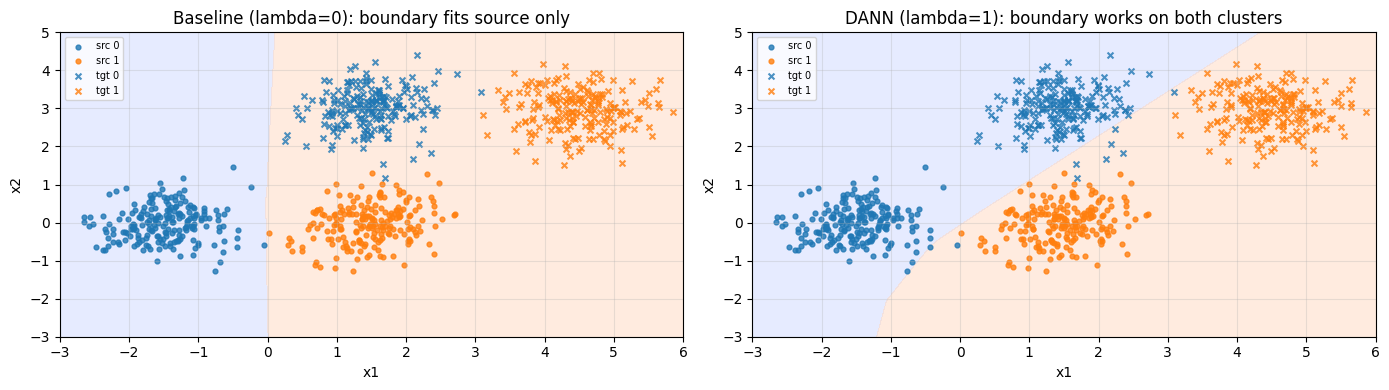

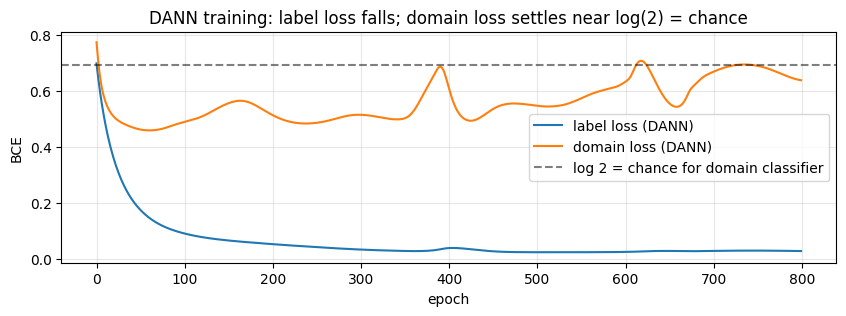

In [8]:
# Decision-region plot
def plot_decision(ax, model, title):
    xs_grid = np.linspace(-3, 6, 200); ys_grid = np.linspace(-3, 5, 120)
    XX, YY = np.meshgrid(xs_grid, ys_grid)
    grid = np.c_[XX.ravel(), YY.ravel()]
    P = model.predict_label(grid).reshape(XX.shape)
    ax.contourf(XX, YY, P, levels=[0, 0.5, 1.0], colors=['#cfd8ff', '#ffd8c0'], alpha=0.5)
    ax.scatter(Xs[ys==0,0], Xs[ys==0,1], c='tab:blue',   marker='o', s=12, alpha=0.8, label='src 0')
    ax.scatter(Xs[ys==1,0], Xs[ys==1,1], c='tab:orange', marker='o', s=12, alpha=0.8, label='src 1')
    ax.scatter(Xt[yt==0,0], Xt[yt==0,1], c='tab:blue',   marker='x', s=18, alpha=0.8, label='tgt 0')
    ax.scatter(Xt[yt==1,0], Xt[yt==1,1], c='tab:orange', marker='x', s=18, alpha=0.8, label='tgt 1')
    ax.set(title=title, xlabel='x1', ylabel='x2')
    ax.legend(loc='upper left', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_decision(axes[0], m_base, 'Baseline (lambda=0): boundary fits source only')
plot_decision(axes[1], m_dann, 'DANN (lambda=1): boundary works on both clusters')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(h_dann[:, 0], label='label loss (DANN)')
ax.plot(h_dann[:, 1], label='domain loss (DANN)')
ax.axhline(np.log(2), ls='--', c='k', alpha=0.5, label='log 2 = chance for domain classifier')
ax.set(title='DANN training: label loss falls; domain loss settles near log(2) = chance',
       xlabel='epoch', ylabel='BCE')
ax.legend(); plt.show()

**Takeaway.** The baseline learns one boundary that fits the source cluster only. DANN forces the trunk to produce features the domain classifier *cannot* exploit, which means features that are invariant to the cluster offset — effectively a kind of learned recentering. Target accuracy jumps from chance (~50%) to near-source level (~98%).

The domain loss curve has a characteristic adversarial shape: it falls early as the domain classifier learns the gap, then climbs back toward $\log 2$ as the trunk learns to hide the difference.

## 6. An honest caveat

DANN is not magic. If the **covariate-shift assumption** $P(y\mid x)=Q(y\mid x)$ fails — i.e. the *labelling rule itself* changes between domains — then aligning marginals can hurt. Exercise 3 below exhibits this failure deliberately.

## 7. Domain generalization: train on K envs, test on the (K+1)-th

No target data at all during training. Following the slides: $K$ labeled environments $\{P^{(e)}\}_{e=1}^K$, find $h$ minimizing risk on a *new* unseen $P^{(K+1)}$.

We use a synthetic time-series classification: predict the trend of a length-8 window. Each environment adds a class-correlated mean offset of varying strength — a spurious shortcut. The held-out env reverses the sign of that correlation. ERM that ignores environment structure will exploit the shortcut and fail; even a simple invariance fixes it.

env 0: mean(class 0)=-2.00  mean(class 1)=+2.01  -> spurious mean-class corr +1
env 1: mean(class 0)=-1.00  mean(class 1)=+0.99  -> spurious mean-class corr +1
env 2: mean(class 0)=-1.50  mean(class 1)=+1.49  -> spurious mean-class corr +1
env 3: mean(class 0)=+2.00  mean(class 1)=-1.99  -> spurious mean-class corr -1


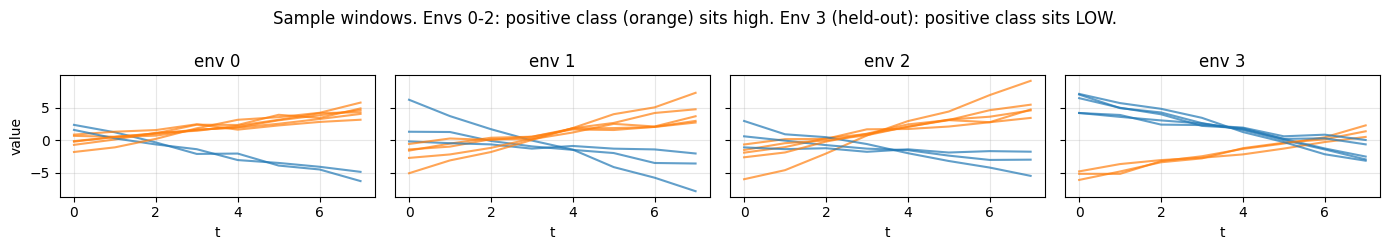

In [9]:
def make_env(env_id, n=400, win=8):
    """y = 1 iff slope > 0 (the *invariant* rule). Each env adds a class-correlated mean
    offset of varying strength — a spurious shortcut. The held-out env reverses the sign."""
    rng_e = np.random.default_rng(env_id + 100)
    spur = {0: +2.0, 1: +1.0, 2: +1.5, 3: -2.0}[env_id]
    slopes = rng_e.normal(0, 1.0, n)
    y = (slopes > 0).astype(int)
    s = 2*y - 1
    t = np.arange(win)
    base   = slopes[:, None] * (t - t.mean())   # zero-mean trend, the invariant signal
    offset = (s * spur)[:, None]                # class-correlated mean (spurious!)
    noise  = rng_e.normal(0, 0.3, (n, win))
    X = base + offset + noise
    return X, y

envs = {e: make_env(e) for e in [0, 1, 2, 3]}
for e, (X, y) in envs.items():
    m0 = X[y==0].mean(); m1 = X[y==1].mean()
    print(f'env {e}: mean(class 0)={m0:+.2f}  mean(class 1)={m1:+.2f}  -> spurious mean-class corr {np.sign(m1-m0):+.0f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 2.5), sharey=True)
for e, ax in zip([0, 1, 2, 3], axes):
    X, y = envs[e]
    for i in range(8):
        col = 'tab:orange' if y[i] == 1 else 'tab:blue'
        ax.plot(X[i], color=col, alpha=0.7)
    ax.set_title(f'env {e}')
    ax.set_xlabel('t')
axes[0].set_ylabel('value')
plt.suptitle('Sample windows. Envs 0-2: positive class (orange) sits high. Env 3 (held-out): positive class sits LOW.')
plt.tight_layout(); plt.show()

In [10]:
Xtr = np.vstack([envs[e][0] for e in [0, 1, 2]])
ytr = np.concatenate([envs[e][1] for e in [0, 1, 2]])
Xte, yte = envs[3]

# Method 1 — Baseline (ERM)
erm = MLPClassifier(hidden_layer_sizes=(16,), max_iter=600, random_state=0).fit(Xtr, ytr)
acc_erm_train = accuracy_score(ytr, erm.predict(Xtr))
acc_erm_test  = accuracy_score(yte, erm.predict(Xte))
print('Baseline (ERM, pool-then-train):')
print(f'  train (envs 0,1,2): {acc_erm_train:.3f}')
print(f'  test  (env 3, OOD): {acc_erm_test:.3f}    <-- ERM exploited the spurious offset')

# Method 2 — Hand-crafted invariance: subtract per-window mean, removing the spurious offset.
def center(X):
    return X - X.mean(axis=1, keepdims=True)

inv = MLPClassifier(hidden_layer_sizes=(16,), max_iter=600, random_state=0).fit(center(Xtr), ytr)
acc_inv_train = accuracy_score(ytr, inv.predict(center(Xtr)))
acc_inv_test  = accuracy_score(yte, inv.predict(center(Xte)))
print('\nInvariance-by-centering (manual feature engineering):')
print(f'  train (envs 0,1,2): {acc_inv_train:.3f}')
print(f'  test  (env 3, OOD): {acc_inv_test:.3f}')

delta = acc_inv_test - acc_erm_test
print(f'\nOOD gain from invariance: {delta:+.3f}')

Baseline (ERM, pool-then-train):
  train (envs 0,1,2): 1.000
  test  (env 3, OOD): 0.022    <-- ERM exploited the spurious offset



Invariance-by-centering (manual feature engineering):
  train (envs 0,1,2): 0.983
  test  (env 3, OOD): 0.985

OOD gain from invariance: +0.963


**Takeaway.** ERM pooled across envs 0–2 picks up the spurious *positive* mean–class correlation those three envs share. When env 3 reverses that correlation, ERM is misled. Subtracting the window mean removes the spurious feature entirely, restoring near-train accuracy on the unseen env. DANN-style adversarial alignment generalizes this idea: instead of choosing the invariance manually, *learn* it by penalising any feature a domain classifier can exploit.

---
# Exercises

## Exercise 1 — Importance reweighting under mild shift

Under covariate shift the optimal source-distributed sample reweighting is $w(x) = P(x)/Q(x)$. With both densities approximately Gaussian, fit them with `multivariate_normal` and reweight source samples.

**Important honesty note:** Importance reweighting only works when source and target *overlap*. Under the heavy shift we used in §5 (shift=3.0), the supports barely intersect and the weights become degenerate. We use a milder shift here.

**Task.** With shift=(1.5, 1.5):

1. Fit $Q(x)$ and $P(x)$ as MVN from source/target empirical mean+cov.
2. Compute $w_i = P(x_i^S)/Q(x_i^S)$, clip to $[0.05, 100]$.
3. Refit `LogisticRegression(...).fit(Xs, ys, sample_weight=w)`.
4. Report source/target accuracy. Compare to unweighted baseline.

In [ ]:
Xs, ys, Xt, yt = make_shifted_clusters(shift=(1.5, 1.5), rng=np.random.default_rng(123))

# 1. fit Q and P as MVN on Xs and Xt (add ~1e-2 jitter to cov for stability)
# 2. compute w = pdf_P(Xs) / pdf_Q(Xs), clip to [0.05, 100]
# 3. fit LogisticRegression(...).fit(Xs, ys, sample_weight=w)
# 4. print src/tgt acc for both naive and reweighted models
pass

### Solution

In [12]:
Q = multivariate_normal(mean=Xs.mean(0), cov=np.cov(Xs.T) + 1e-2*np.eye(2))
P = multivariate_normal(mean=Xt.mean(0), cov=np.cov(Xt.T) + 1e-2*np.eye(2))
w = P.pdf(Xs) / np.clip(Q.pdf(Xs), 1e-9, None)
w = np.clip(w, 0.05, 100.0)

clf_iw    = LogisticRegression().fit(Xs, ys, sample_weight=w)
clf_naive = LogisticRegression().fit(Xs, ys)

print(f'{"method":>22}  {"src acc":>7}  {"tgt acc":>7}')
print('-' * 40)
print(f'{"naive (no reweight)":>22}  {accuracy_score(ys, clf_naive.predict(Xs)):>7.3f}  {accuracy_score(yt, clf_naive.predict(Xt)):>7.3f}')
print(f'{"importance reweight":>22}  {accuracy_score(ys, clf_iw.predict(Xs)):>7.3f}  {accuracy_score(yt, clf_iw.predict(Xt)):>7.3f}')
print(f'\nWeights summary:  min={w.min():.3f}  median={np.median(w):.3f}  max={w.max():.3f}')

# Honest note: under heavier shifts, reweighting fails entirely — it relies on overlap of supports.
print('\nNote: reweighting only buys you a little here, and would buy you nothing at shift=3.0,')
print('because the source and target supports barely overlap. This is a known limitation of the method.')

                method  src acc  tgt acc
----------------------------------------
   naive (no reweight)    0.998    0.757
   importance reweight    1.000    0.700

Weights summary:  min=0.050  median=0.050  max=40.466

Note: reweighting only buys you a little here, and would buy you nothing at shift=3.0,
because the source and target supports barely overlap. This is a known limitation of the method.


## Exercise 2 — H-divergence: scratch vs library

Re-implement the H-divergence estimator using **only** numpy. Use a single linear classifier optimised by SGD on hinge loss for ~200 epochs. Compare against the §3 sklearn-based estimator.

Verify the two agree to within a small tolerance using `np.allclose`.

In [ ]:
Xs_e2, _, Xt_e2, _ = make_shifted_clusters(shift=(2.0, 2.0), rng=np.random.default_rng(11))

# 1. stack data, label src=+1, tgt=-1 (hinge convention)
# 2. SGD on hinge loss for ~200 epochs to fit a linear classifier (w, b)
# 3. compute training error of best classifier
# 4. d_H = 2 * (1 - eps_class)
# 5. compare to h_divergence(Xs_e2, Xt_e2, 'linear')
pass

### Solution

In [14]:
def h_divergence_scratch(Xs, Xt, lr=0.05, epochs=200, seed=0):
    rng_e = np.random.default_rng(seed)
    X = np.vstack([Xs, Xt])
    y = np.concatenate([np.ones(len(Xs)), -np.ones(len(Xt))])  # +/-1 hinge convention
    perm = rng_e.permutation(len(X))
    X, y = X[perm], y[perm]
    w = rng_e.normal(0, 0.1, X.shape[1]); b = 0.0
    for _ in range(epochs):
        margins = y * (X @ w + b)
        active = margins < 1
        if active.any():
            gw = -(y[active][:, None] * X[active]).mean(0)
            gb = -y[active].mean()
        else:
            gw = np.zeros_like(w); gb = 0.0
        w -= lr * gw; b -= lr * gb
    preds = np.sign(X @ w + b)
    eps_class = (preds != y).mean()
    return 2 * (1 - eps_class)

d_scratch = h_divergence_scratch(Xs_e2, Xt_e2)
d_lib, _  = h_divergence(Xs_e2, Xt_e2, 'linear')

print(f'd_H scratch (numpy hinge SGD)  = {d_scratch:.3f}')
print(f'd_H library (sklearn logistic) = {d_lib:.3f}')
print(f'max abs diff                   = {abs(d_scratch - d_lib):.3f}')
assert np.isclose(d_scratch, d_lib, atol=0.15), 'should agree to within 0.15'
print('OK - both estimators agree on the divergence within 0.15.')

d_H scratch (numpy hinge SGD)  = 1.958
d_H library (sklearn logistic) = 1.958
max abs diff                   = 0.000
OK - both estimators agree on the divergence within 0.15.


## Exercise 3 — DANN failure mode (concept-shift trap)

DANN's whole pitch is: align $P(x)$ and $Q(x)$ in feature space. But what if $P(y\mid x)\ne Q(y\mid x)$ — i.e. the *labelling rule itself* flips? Then the marginals are *already aligned*, so DANN does nothing useful, and there is no information in the unlabeled target $X^T$ that could possibly fix the relabelling.

**Task.** Build a problem where source and target have the same $P(x)$ marginal but **flipped** labelling rules (source: label by $\text{sign}(x_1)$; target: label by $\text{sign}(-x_1)$). Train DANN with $\lambda=1$ and the no-adaptation baseline. *Predict* what happens before running.

In [ ]:
def make_concept_shift(n=400, rng=rng):
    Xs = rng.normal(0, 1, (n, 2))
    Xt = rng.normal(0, 1, (n, 2))   # same marginal!
    ys = (Xs[:, 0] > 0).astype(int)
    yt = (Xt[:, 0] < 0).astype(int)  # flipped rule
    return Xs, ys, Xt, yt

Xs_c, ys_c, Xt_c, yt_c = make_concept_shift()

# 1. train DANN(lam=0) and DANN(lam=1) using train_dann(...)
# 2. report src and tgt accuracy for both models
# 3. note in 1 sentence why this is a failure mode
pass

### Solution

In [16]:
m_b, _ = train_dann(Xs_c, ys_c, Xt_c, lam=0.0, epochs=400)
m_d, _ = train_dann(Xs_c, ys_c, Xt_c, lam=1.0, epochs=400)

# Also compute H-divergence between the two unlabeled marginals
d_marg, _ = h_divergence(Xs_c, Xt_c, 'linear')

print(f'{"model":>14}  {"src acc":>8}  {"tgt acc":>8}')
print('-' * 36)
print(f'{"baseline":>14}  {acc(m_b, Xs_c, ys_c):>8.3f}  {acc(m_b, Xt_c, yt_c):>8.3f}')
print(f'{"DANN":>14}  {acc(m_d, Xs_c, ys_c):>8.3f}  {acc(m_d, Xt_c, yt_c):>8.3f}')
print(f'\nH-divergence on unlabeled X: d_H = {d_marg:.3f}  (close to chance level => marginals already match)')
print('\nNeither method exceeds chance on target. The marginals already match, so DANN has nothing to align,')
print('and the true issue (flipped y|x rule) is invisible to any method that only sees unlabeled target X.')
print('Moral: DANN solves covariate shift, not concept shift. Always check the assumption first.')

         model   src acc   tgt acc
------------------------------------
      baseline     0.990     0.022
          DANN     0.990     0.020

H-divergence on unlabeled X: d_H = 1.042  (close to chance level => marginals already match)

Neither method exceeds chance on target. The marginals already match, so DANN has nothing to align,
and the true issue (flipped y|x rule) is invisible to any method that only sees unlabeled target X.
Moral: DANN solves covariate shift, not concept shift. Always check the assumption first.


---
## Recap

| Concept                       | Formula / definition                                                                                          | When to use                                                |
|------------------------------|---------------------------------------------------------------------------------------------------------------|------------------------------------------------------------|
| Domain shift                 | $Q_{X,Y}\ne P_{X,Y}$                                                                                          | Whenever deployment data is not iid with training          |
| Covariate shift              | $Q(y\mid x)=P(y\mid x)$ but $Q(x)\ne P(x)$                                                                    | The standard DA assumption — always verify it              |
| $\mathcal{H}$-divergence     | $2\sup_{h\in\mathcal{H}}\bigl|\Pr_Q[h{=}1]-\Pr_P[h{=}1]\bigr|$                                                | Quantify how distinguishable two domains are               |
| Domain-classifier estimator  | $\tfrac{1}{2}d_{\mathcal{H}} \approx 1-\epsilon_{\text{class}}$                                                | Practical estimate from finite unlabeled samples           |
| Main bound (Ben-David et al.)| $\epsilon_T(h)\le \epsilon_S(h)+\tfrac12 d_{\mathcal{H}\Delta\mathcal{H}}+\epsilon_{\text{joint}}$            | Justifies feature-alignment methods                        |
| Importance reweighting       | $w(x)=P(x)/Q(x)$                                                                                              | Mild shifts with overlapping supports; fails under heavy shift |
| DANN (Ganin & Lempitsky)     | $\min_{\theta_f,\theta_y}\max_{\theta_d}\mathcal{L}_y - \lambda\mathcal{L}_d$ via gradient reversal           | Learn invariant features end-to-end with DL                |
| Domain generalization (OOD)  | Train on $K$ envs, test on unseen $K{+}1$                                                                     | When no target data is available even unlabeled            |
| ERM vs invariance for DG     | ERM = pool-and-train; invariance = remove env-specific structure (centering, DANN, IRM, ...)                  | Compare baseline to anything before claiming OOD gains     |